# Klasifikasi Posisi Pemain Sepak Bola dengan Support Vector Machine (SVM)
Tugas Kelompok - P17 Anggota Kelompok:

1.   Muhammad Fadhil Aprilino (24523175)
2.   --

Dataset: Football Players Data (fifa_players.csv)

Sumber: kaggle ( https://www.kaggle.com/datasets/maso0dahmed/football-players-data?select=fifa_players.csv )

Deskripsi: Dataset ini berisi data dari pemain sepak bola dengan jumlah sekitar 17.000 yang diambil dari SoFIFA.com. Setiap pemain memiliki atribut skill yang lengkap seperti:
- Kemampuan fisik: sprint_speed, stamina, jumping, acceleration
- Kemampuan teknis: dribbling, passing, finishing, ball_control
- Kemampuan bertahan: interceptions, marking, sliding_tackle

tujuan dari membangun model Support Vector Machine (SVM) ini adalah untuk mengklasifikasi posisi utama pemain menjadi 4 kategori seperti :


*   label - posisi
*   0 - Goalkeeper (GK)
*   1 - Defender (CB, LB, RB)
*   2 - Midfielder (CM, CAM, CDM)
*   3 - Forward (ST, LW, RW)


## 1. Import Library

###  Library utama yang digunakan:
1. NumPy & Pandas - manipulasi dan analisis data tabular
2. Matplotlib & Seaborn - visualisasi data
3. Scikit-learn - preprocessing, pemodelan SVM, dan evaluasi model

In [29]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

##2. Load dataset

In [30]:
df = pd.read_csv('fifa_players.csv')

print(f'jumlah baris: {df.shape[0]:,} pemain')
print(f'jumlah kolom: {df.shape[1]} atribut')
print()
df.head()

jumlah baris: 17,954 pemain
jumlah kolom: 51 atribut



,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [31]:
print('informasi untuk kolom dataset:')
df.info()

print('deskripsi statistik(beberapa kolom saja):')
kolom_contoh = ['overall_rating', 'potential', 'finishing', 'dribbling', 'sprint_speed', 'standing_tackle']
kolom_ada = [k for k in kolom_contoh if k in df.columns]
df[kolom_ada].describe().round(2)

informasi untuk kolom dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot 

,overall_rating,potential,finishing,dribbling,sprint_speed,standing_tackle
count,17954.00,17954.00,17954.00,17954.00,17954.00,17954.00
mean,66.24,71.43,45.36,55.28,64.80,47.73
std,6.96,6.13,19.64,19.09,14.72,21.67
min,47.00,48.00,2.00,4.00,12.00,2.00
25%,62.00,67.00,30.00,49.00,58.00,27.00
50%,66.00,71.00,49.00,61.00,67.00,55.00
75%,71.00,75.00,62.00,68.00,75.00,66.00
max,94.00,95.00,95.00,97.00,96.00,93.00


##3. Preprocessing Data

### Langkah-langkah preprocessing yang dilakukan:
1. Membuat label posisi - mengelompokkan posisi spesifik (ST, CAM, CB, dst.) menjadi 4 posisi utama
2. Memilih fitur skill - hanya menggunakan atribut kemampuan bermain yang numerik
3. Menangani missing value - mengisi nilai kosong dengan median kolom tersebut
4. Encoding label - mengubah nama posisi (string) menjadi angka menggunakan LabelEncoder
5. Feature Scaling - normalisasi dengan StandardScaler supaya SVM bekerja optimal

In [32]:
#membuat label posisi
#mengelompokkan menjadi 4 posisi utama karena banyak posisi yang spesifik di kolom "posisi" saat ini
def kelompok_posisi(pos):
    if pd.isna(pos):
        return None
    pos = str(pos).upper()
    if 'GK' in pos:
        return 'Goalkeeper'
    elif any(p in pos for p in ['CB','LB','RB','LWB','RWB','SW']):
        return 'Defender'
    elif any(p in pos for p in ['CM','CAM','CDM','LM','RM','AM']):
        return 'Midfielder'
    elif any(p in pos for p in ['ST','CF', 'LW','RW','SS','LS','RS']):
        return 'Forward'
    else:
        return None

df['posisi_utama'] = df['positions'].apply(kelompok_posisi)

#menghapus baris yang posisinya tidak bisa dikelompokkan
df = df.dropna(subset=['posisi_utama']).reset_index(drop=True)

print(f'sisa data setelah filtering: {len(df):,} pemain')
print()
print('distribusi posisi:')
print(df['posisi_utama'].value_counts())

sisa data setelah filtering: 17,954 pemain

distribusi posisi:
posisi_utama
Midfielder    6829
Defender      6571
Forward       2489
Goalkeeper    2065
Name: count, dtype: int64


In [33]:
#lanjut ke memilih fitur skill
#Fitur yang dipilih ini adalah atribut skill pemain yang relevan untuk digunakan
#fitur non-skill yang tidak digunakan itu seperti (nama,klub,nilai transfer,nomor jersey dan yang lainnya)

fitur_skill = ['overall_rating', 'potential','crossing', 'finishing', 'heading_accuracy','short_passing', 'volleys', 'dribbling','curve', 'freekick_accuracy', 'long_passing','ball_control', 'acceleration', 'sprint_speed','agility', 'reactions', 'balance', 'shot_power','jumping', 'stamina', 'strength', 'long_shots','aggression', 'interceptions', 'positioning','vision', 'penalties', 'composure','marking', 'standing_tackle', 'sliding_tackle']

fitur_tersedia = [f for f in fitur_skill if f in df.columns]
print(f'total fitur yang digunakan: {len(fitur_tersedia)}')
print(f'{fitur_tersedia}')

total fitur yang digunakan: 31
['overall_rating', 'potential', 'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'freekick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'composure', 'marking', 'standing_tackle', 'sliding_tackle']


In [34]:
#lanjut ke menangani missing value
#cek missing value
print('Missing Values:')
print(df[fitur_tersedia].isnull().sum())

df[fitur_tersedia] = df[fitur_tersedia].fillna(df[fitur_tersedia].median(numeric_only=True))

print('missing values setelah imputasi median:')
print(df[fitur_tersedia].isnull().sum().sum(), '(total)')

Missing Values:
overall_rating       0
potential            0
crossing             0
finishing            0
heading_accuracy     0
short_passing        0
volleys              0
dribbling            0
curve                0
freekick_accuracy    0
long_passing         0
ball_control         0
acceleration         0
sprint_speed         0
agility              0
reactions            0
balance              0
shot_power           0
jumping              0
stamina              0
strength             0
long_shots           0
aggression           0
interceptions        0
positioning          0
vision               0
penalties            0
composure            0
marking              0
standing_tackle      0
sliding_tackle       0
dtype: int64
missing values setelah imputasi median:
0 (total)


In [35]:
#lanjut ke encoding label
#mengubah defender->0, forward->1, goalkeeper->2, midfielder->3 (sesuai urutan abjad)

le = LabelEncoder()
df['posisi_encoded'] = le.fit_transform(df['posisi_utama'])

print('Mapping label (urutan alfabet):')
for angka, nama in enumerate(le.classes_):
    jumlah = (df['posisi_encoded'] == angka).sum()
    print(f'  {angka} = {nama:<12} ({jumlah:,} pemain)')

Mapping label (urutan alfabet):
  0 = Defender     (6,571 pemain)
  1 = Forward      (2,489 pemain)
  2 = Goalkeeper   (2,065 pemain)
  3 = Midfielder   (6,829 pemain)


## 4. Split data

### Data dibagi jadi dua bagian:
- Training set (80%) - digunakan untuk melatih model SVM
- Test set (20%) - digunakan untuk mengevaluasi performa model pada data baru

sesudah split, standardscaler di-fit pada data training, lalu hasilnya digunakan di keduanya,untuk mencegah data leakage (informasi test set bocor ke proses training).

In [36]:
#split data = 80% training, 20% testing
x = df[fitur_tersedia].values
y = df['posisi_encoded'].values
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

print(f'jumlah data training : {X_train.shape[0]:,} sampel')
print(f'jumlah data testing  : {X_test.shape[0]:,} sampel')

jumlah data training : 14,363 sampel
jumlah data testing  : 3,591 sampel


In [37]:
# Feature scaling menggunakan standardscaler
# Mengubah data  setiap fitur memiliki mean=0 dan standard=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'mean sebelum scaling (fitur 1): {X_train[:, 0].mean():.2f}')
print(f'mean sesudah scaling (fitur 1): {X_train_scaled[:, 0].mean():.6f} (~0)')
print(f'standard sesudah scaling (fitur 1): {X_train_scaled[:, 0].std():.6f} (~1)')

mean sebelum scaling (fitur 1): 66.25
mean sesudah scaling (fitur 1): 0.000000 (~0)
standard sesudah scaling (fitur 1): 1.000000 (~1)


## 5. Model SVM

### Kernel yang Digunakan: RBF (Radial Basis Function)

Alasan memilih kernel RBF:  
Kemampuan pemain sepak bola tidak bisa dipisahkan secara linear. Misalnya, Midfielder dan Forward sama-sama punya dribbling dan ball_control tinggi, tapi ada  perbedaan signifikan di finishing dan standing_tackle.Kernel RBF memetakan data tersebut ke dimensi tak terhingga menggunakan fungsi Gaussian K(x, xi) = exp(-γ · Σ(x - xi)²), sehingga bisa menangkap pola non-linear tersebut.

In [38]:
svm_model = SVC(kernel='rbf',C=1.0,gamma='scale',decision_function_shape='ovo',random_state=42)
svm_model.fit(X_train_scaled, y_train)

print(f'Kernel yang digunakan : {svm_model.kernel}')
print(f'Nilai C (regularisasi): {svm_model.C}')
print(f'Nilai gamma: {svm_model.gamma}')
print(f'Jumlah Support Vectors per kelas:')
for nama, jumlah in zip(le.classes_,svm_model.n_support_):
    print(f'{nama:<12}: {jumlah:,} support vectors')

Kernel yang digunakan : rbf
Nilai C (regularisasi): 1.0
Nilai gamma: scale
Jumlah Support Vectors per kelas:
Defender    : 1,142 support vectors
Forward     : 990 support vectors
Goalkeeper  : 33 support vectors
Midfielder  : 2,089 support vectors


## 6. Evaluasi model

In [39]:
y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print('hasil evaluasi model SVM:')
print(f'Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'Precision : {precision:.4f}  ({precision*100:.2f}%)')
print(f'Recall    : {recall:.4f}  ({recall*100:.2f}%)')
print(f'F1 Score  : {f1:.4f}  ({f1*100:.2f}%)')

hasil evaluasi model SVM:
Accuracy  : 0.8981  (89.81%)
Precision : 0.9007  (90.07%)
Recall    : 0.8981  (89.81%)
F1 Score  : 0.8978  (89.78%)


### deskripsi singkat untuk hasil evaluasi model SVM:
  1. Model berhasil mengklasifikasikan 89.81% dari 3.591 data test dengan benar.
  2. Precision 90.07%: dari semua prediksi suatu posisi, rata-rata 90.07% memang sudah benar.
  3. Recall 89.81%: dari semua pemain suatu posisi, rata-rata 89.81% berhasil diidentifikasi.
  4. F1 Score 89.78%: keseimbangan precision dan recall secara keseluruhannya sudah sangat baik.

In [40]:
#classification report lengkap per posisi
#menampilkan precision, recall, f1-score untuk setiap kelas posisi
print('classification report per Posisi:')
print(classification_report(y_test, y_pred,target_names=le.classes_))

classification report per Posisi:
              precision    recall  f1-score   support

    Defender       0.96      0.91      0.93      1314
     Forward       0.85      0.73      0.79       498
  Goalkeeper       1.00      1.00      1.00       413
  Midfielder       0.83      0.92      0.87      1366

    accuracy                           0.90      3591
   macro avg       0.91      0.89      0.90      3591
weighted avg       0.90      0.90      0.90      3591



### deskripsi singkat per posisi:
  - Goalkeeper (F1=1.00) : Paling mudah diklasifikasikan karena atribut
  kiper (diving, handling) paling berbeda dari posisi lainnya.
  - Defender (F1=0.93) : Sangat baik. Atribut bertahan (marking,
  standing_tackle) yang membuat perbedaan dengan jelas.
  - Midfielder (F1=0.87) : Baik, tapi ada overlap atribut dengan
  Defender seperti (interceptions, vision) yang membuat sedikit lebih sulit dibedakan.
  - Forward (F1=0.79) : Paling rentan, ada overlap skill dribbling
  dan ball_control dengan Midfielder, yang membuat F1 paling rendah.

In [41]:
#analisis overfitting dan underfitting
# membandingkan akurasi di data training vs data testing
training_acc = svm_model.score(X_train_scaled, y_train)
testing_acc = svm_model.score(X_test_scaled, y_test)
gap = training_acc - testing_acc
print(f'Training Accuracy: {training_acc:.4f} ({training_acc*100:.2f}%)')
print(f'Test Accuracy: {testing_acc:.4f} ({testing_acc*100:.2f}%)')
print(f'Selisih (Gap): {gap:.4f} ({gap*100:.2f}%)')

Training Accuracy: 0.9050 (90.50%)
Test Accuracy: 0.8981 (89.81%)
Selisih (Gap): 0.0069 (0.69%)


### kesimpulan: model dalam kondisi good fit
akurasi training dan test seimbang serta memiliki nilai yang cukup tinggi.
model mampu menggeneralisasi dengan baik ke data baru.

Analisis Singkat:
gap antara training accuracy (90.50%) dan test accuracy (89.81%)
sebesar 0.69%. yang menunjukkan model tidak overfitting ataupun underfitting. yang menandakan kernel RBF dengan C= 1.0 dan gamma= "scale" memberikan generalisasi yang sangat baik pada dataset Football Players Data yang berisi 17.954 pemain.

##7. Visualisasi

### Distribusi kelas

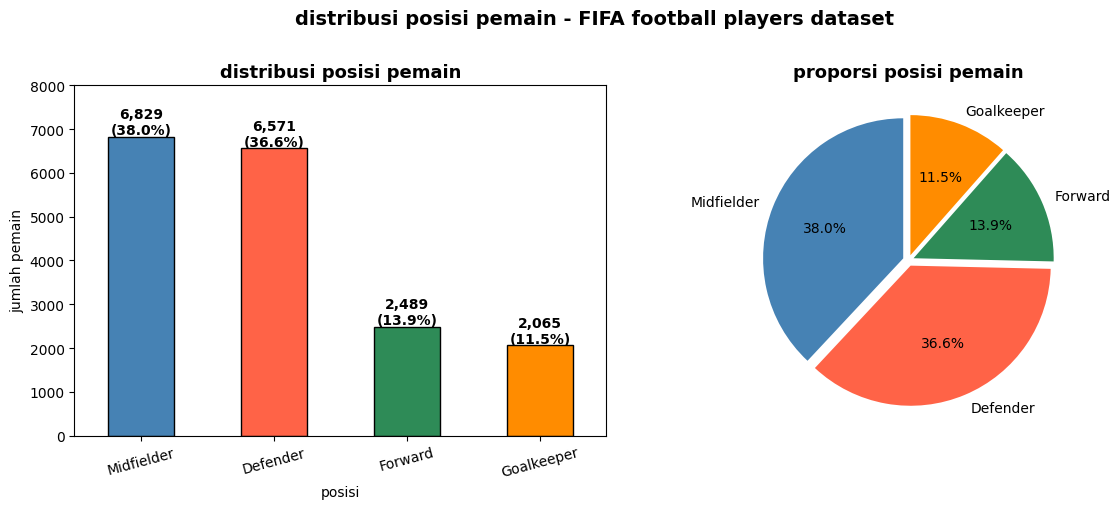

In [42]:

jumlah_posisi = df['posisi_utama'].value_counts()
label_posisi  = jumlah_posisi.index.tolist()
warna = ['steelblue','tomato','seagreen','darkorange']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

#bar chart
jumlah_posisi.plot(kind='bar', ax=ax1, color=warna, edgecolor='black', rot=0)
ax1.set_title('distribusi posisi pemain', fontsize=13, fontweight='bold')
ax1.set_xlabel('posisi')
ax1.set_ylabel('jumlah pemain')
ax1.set_xticklabels(label_posisi, rotation=15)
ax1.set_ylim(0,8000)
for i, v in enumerate(jumlah_posisi):
    ax1.text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)',
             ha='center',fontweight='bold',fontsize=10)

#pie chart
ax2.pie( jumlah_posisi, labels=label_posisi,colors=warna, autopct='%1.1f%%', startangle=90, explode=[0.04]*len(jumlah_posisi))
ax2.set_title('proporsi posisi pemain',fontsize=13,fontweight='bold')

plt.suptitle('distribusi posisi pemain dari FIFA football players dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

###Confusion matrix

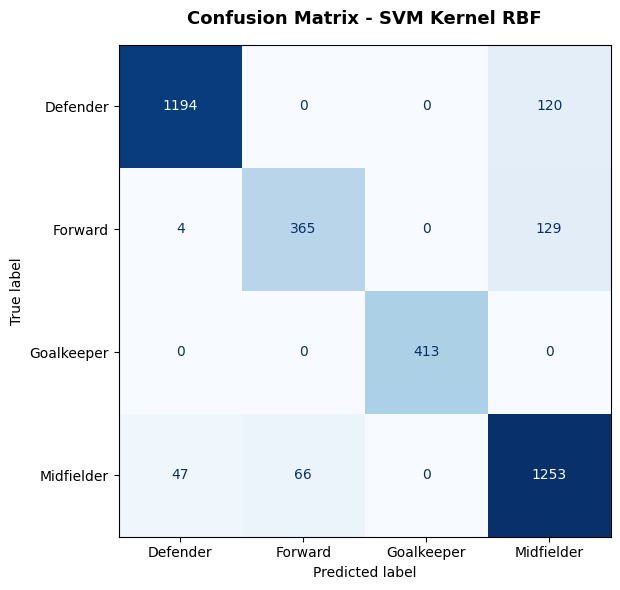

In [43]:
cm = confusion_matrix(y_test,y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix dari SVM Kernel RBF', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### deskripsi singkat confusion matrix

Berdasarkan confusion matrix di atas:
1. Goalkeeper tidak salah diklasifikasikan sama sekali karena semua 413 sampel diprediksi benar. yanbg menandakan konsisten dengan F1=1.00 pada classification report.
2. Defender cukup baik dengan sedikit kebingungan ke Midfielder, karena keduanya sama-sama punya atribut interceptions dan aggression yang tinggi.
3. Midfielder paling sering terkonfusi dengan Defender karena posisi CDM (defensive midfielder) memiliki atribut bertahan yang mirip dengan Defender.
4. Forward paling banyak salah diklasifikasikan, terutama ke Midfielder.  karena winger (LW/RW) memiliki dribbling dan ball_control tinggi yang mirip dengan Midfielder.

### visualisasi perbandingan skill antar posisi

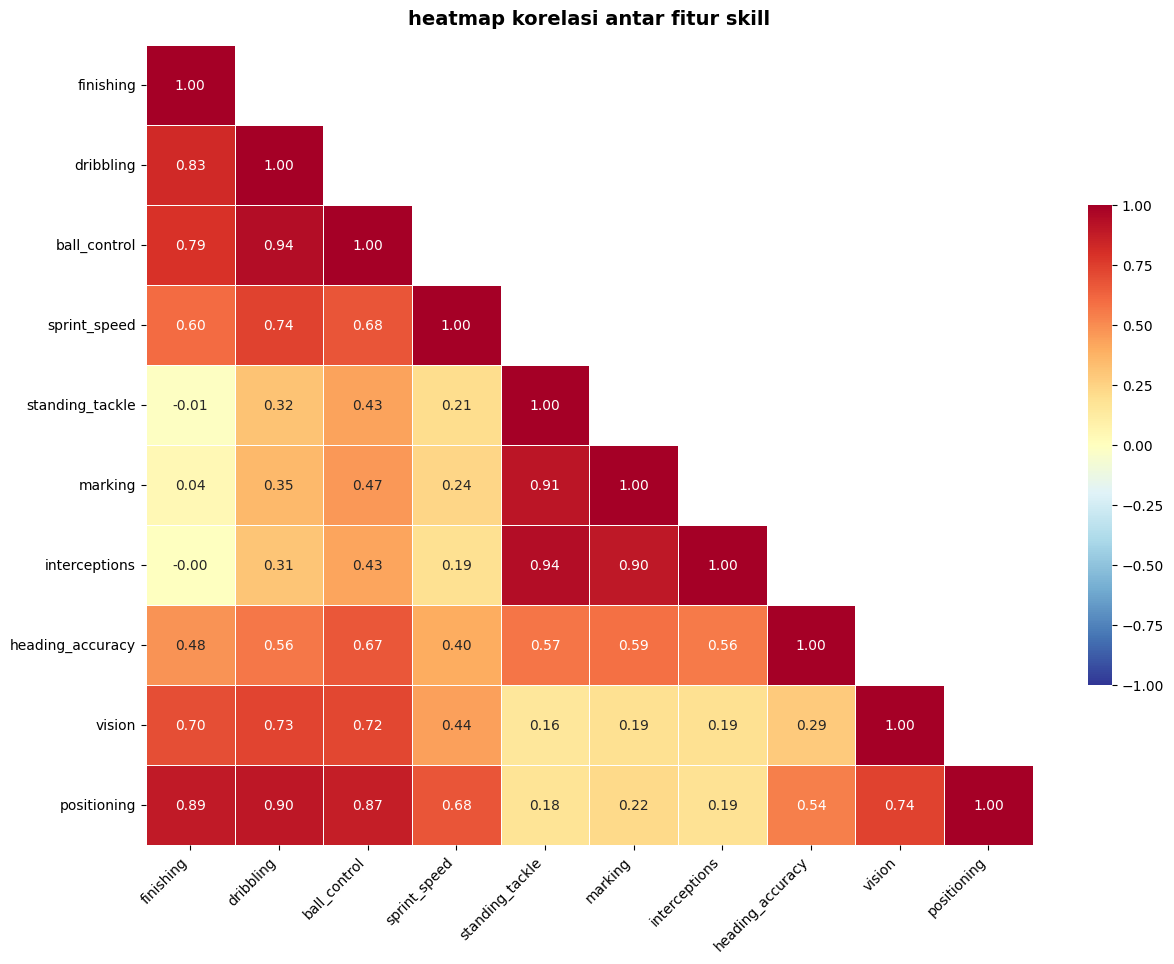

In [49]:
#visualisasi sederhana:heatmap korelasi antar fitur skill

fitur_korelasi = ['finishing', 'dribbling', 'ball_control', 'sprint_speed','standing_tackle', 'marking', 'interceptions','heading_accuracy', 'vision', 'positioning']

fig, ax = plt.subplots(figsize=(13, 10))
korelasi = df[fitur_korelasi].corr()

mask = np.triu(np.ones_like(korelasi, dtype=bool), k=1)
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, linewidths=0.5, linecolor='white',
            vmin=-1, vmax=1, center=0,
            square=False,
            cbar_kws={'shrink': 0.6},
            ax=ax, annot_kws={'size': 10})

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

ax.set_title('heatmap korelasi antar fitur skill', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(pad=2.0)
plt.show()


#### deskripsi singkat heatmap korelasi:

1. Finishing & positioning berkorelasi tinggi positif karena pemain yang bagus dalam positioning biasanya tajam dalam finishing,seperti Forward.
2. Standing_tackle & marking & interceptions berkorelasi kuat satu sama lain karena ketiganya adalah atribut bertahan yang dimiliki Defender, yang membuat ketiganya nilainya naik-turun bersama.
3. Dribbling & ball_control sangat berkorelasi karena inilah sumber kebingungan antara Midfielder dan Forward, karena keduanya memiliki nilai tinggi di kedua atribut ini.
4. Finishing vs standing_tackle berkorelasi negatif karena pemain dengan finishing tinggi (Forward) cenderung punya standing_tackle rendah, dan sebaliknya. Ini adalah pasangan fitur paling diskriminatif untuk membedakan Forward dari Defender.


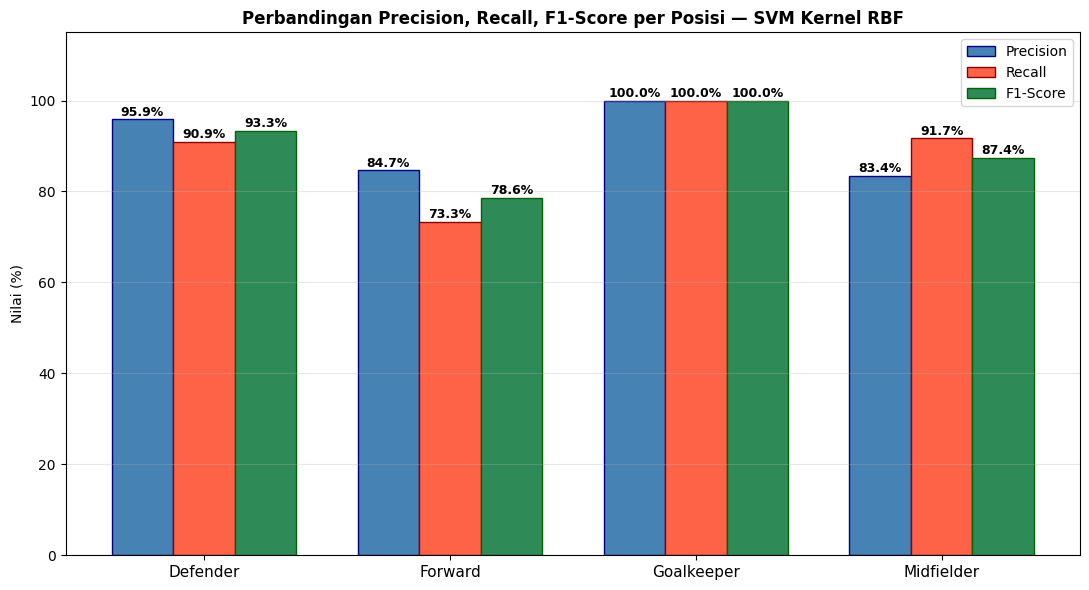

In [45]:
#visualisasi sederhana:bar chart precision, recall, f1 per posisi
posisi_label = le.classes_
precision_per = precision_score(y_test, y_pred, average=None)
recall_per = recall_score(y_test, y_pred, average=None)
f1_per = f1_score(y_test, y_pred, average=None)

x = np.arange(len(posisi_label))
lebar = 0.25
warna = ['steelblue','tomato','seagreen']

fig, ax = plt.subplots(figsize=(11, 6))

b1 = ax.bar(x-lebar,precision_per*100,lebar,label='Precision',color=warna[0],edgecolor='navy')
b2 = ax.bar(x,recall_per*100,lebar,label='Recall',color=warna[1],edgecolor='darkred')
b3 = ax.bar(x+lebar,f1_per*100,lebar,label='F1-Score',color=warna[2],edgecolor='darkgreen')

for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.8,f'{bar.get_height():.1f}%', ha='center',fontsize=9,fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(posisi_label, fontsize=11)
ax.set_ylabel('Nilai (%)')
ax.set_ylim(0, 115)
ax.set_title('perbandingan precision, recall, f1-score per posisi dari SVM Kernel RBF',fontsize=12,fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### deskripsi singkat perbandingan metrik per posisi:

1. Goalkeeper memiliki Precision, Recall, dan F1 sempurna (100%) karena atribut kiper sangat unik sehingga model tidak pernah salah mengidentifikasinya.
2. Defender mendapat F1=93% dengan Precision lebih tinggi dari Recall karena model sangat yakin saat memprediksi Defender, tapi ada sejumlah Defender yang salah diklasifikasikan sebagai Midfielder.
3. Midfielder memiliki Recall (92%) lebih tinggi dari Precision (83%) karena model cenderung 'terlalu agresif' melabeli pemain sebagai Midfielder, termasuk beberapa Forward.
4. Forward mendapat F1 terendah (79%) karena Recall hanya 73% karena banyak Forward yang gagal diidentifikasi, kemungkinan besar diklasifikasikan sebagai Midfielder karena overlap skill.
